### PS-S06E05: CatBoost

This notebook tackles the [**Playground Series – Season 6, Episode 5: Predicting F1 Pit Stops**](https://www.kaggle.com/competitions/playground-series-s6e5), a competition focused on predicting the probabilty that a driver will pit on the next lap, based on with engineered features that capture tire degradation, race progression, and driver performance dynamics.

CatBoost is a strong baseline for tabular problems and often complements XGBoost/LightGBM in ensembles because it handles categorical features natively and robustly.

In this notebook we:
- Apply lightweight, physics-based feature engineering per fold (to avoid leakage)
- Train a **CatBoostClassifier** using **Stratified 5-Fold Cross-Validation**.
- Optimize for **Balanced Accuracy**, the primary evaluation metric for this competition.
- Collect **Out-of-Fold (OOF) probabilities** and test-set predictions for downstream ensembling.

## Install Needed Packages

In [1]:
import os
import gc
import sys
import math
import random
import warnings

# Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
import torch
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import RFECV
from catboost import CatBoostClassifier, Pool, EFstrType, EFeaturesSelectionAlgorithm, EShapCalcType

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e05_feature_engineering import FeatureFactory
from ps_s06e05_model_visualizer import ModelVisualizer
from ps_s06e05_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# Target label column for S06E03
TARGET = 'PitNextLap'

# GPU usage (set True only if your environment supports CatBoost GPU)
USE_GPU = True

# Optional: Recursive Feature Elimination
PERFORM_RFE = False

# Optional: Optuna tuning
PERFORM_OPTUNA_TUNING = True

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0    39.000         8       78.491         -7.564                  21.019   
1     7.000         4       75.095        -32.617                -223.207   
2    22.000        13       70.945         -7.540                -100.529   
3     2.000         7       94.361         -7.324                  -7.324   
4     6.000         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id Driver Compound                      Race  Year  PitStop  LapNumber  \
0  439140   D119   MEDIUM        British Grand Prix  2023        0         21   
1  439141    VER   MEDIUM      Abu Dhabi Grand Prix  2023        0         24   
2  439142   D270   MEDIUM        British Grand Prix  2023        0         24   
3  439143   D112     SOFT      São Paulo Grand Prix  2024        0          6   
4  439144    AND     HARD  United States Grand Prix  2024        0         52   

   Stint  TyreLife  Position  LapTime (s)  LapTime_Delta  \
0      1    21.000         4       93.387          0.280   
1      1    24.000         1       90.867         -0.129   
2      1    24.000        11       92.871          0.041   
3      2     4.000        15       94.967        -19.741   
4      2    29.000        12       99.112          0.930   

   Cumulative_Degradation  RaceProgress  Position_Change  
0                  -4.984         0.404            0.000  
1                  -

## Feature Engineering Strategy

We apply a set of feature engineering steps designed to capture the relationship between soil conditions and atmospheric demand:

- `encoding`: Standardizes numeric features.
- `ratios`: Calculates features like the **Vapor Pressure Deficit (VPD)**, which represents the atmospheric "pull" on soil moisture.
- `interactions`: Creates terms between multiple features, such as a feature created based on `Soil_Type` and `Soil_Moisture` to account for varying water-holding capacities.
- `binning`: Groups continuous variables like `Temperature_C` into lifecycle stages.

**Categorical Handling**: We pass categorical fields like `Soil_Type`, `Crop_Type`, and `Region` directly to CatBoost. This allows the model to learn complex non-linear splits without the need for manual one-hot encoding.

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'encoding',
    'race_dynamics',
    'tire_physics',
]

In [6]:
print('Performing initial feature engineering.')

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Target labels
y = training_df[TARGET]

# Fit_transform on training, transform on test
X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

cat_features = feature_engineer.get_cat_features(X)
print(f'Feature Count: {X.shape[1]}')
print(f'CatBoost categorical features ({len(cat_features)}): {cat_features}')
print(f'Target sample: {y.head()}')
display(X.head())

Performing initial feature engineering.
Feature Count: 23
CatBoost categorical features (0): []
Target sample: 0   1.000
1   0.000
2   1.000
3   0.000
4   0.000
Name: PitNextLap, dtype: float64


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,TotalLaps,LapsRemaining,PositionVolatility,RemainingRace,StintProgress,PositionChange,DegradationRate,Log_Degradation,LogWear
0,134,0,7,2022,0,50,2,39.000,8,78.491,-7.564,21.019,0.714,5.000,70.000,20.000,5.000,0.286,0.765,0.000,0.525,3.092,3.689
1,111,0,9,2025,1,27,2,7.000,4,75.095,-32.617,-223.207,0.346,-3.000,78.000,51.000,3.000,0.654,0.250,-4.000,-27.901,-5.413,2.079
2,886,0,2,2022,0,59,3,22.000,13,70.945,-7.540,-100.529,0.819,3.000,72.000,13.000,3.000,0.181,0.367,9.000,-4.371,-4.620,3.135
3,864,2,19,2023,0,2,1,2.000,7,94.361,-7.324,-7.324,0.077,0.000,26.000,24.000,0.000,0.923,0.667,-6.000,-2.441,-2.119,1.099
4,44,0,3,2022,1,26,3,6.000,2,107.878,8.965,-14.139,0.361,3.000,72.000,46.000,3.000,0.639,0.222,-5.000,-2.020,-2.717,1.946


In [7]:
# Categorical columns for this competition (integer-coded)
cat_cols = feature_engineer.get_cat_features(X)

cat_cols = [c for c in cat_cols if c in X.columns]
print(f'Categorical Features: {cat_cols}')

# CatBoost accepts categoricals as either int codes or strings. We keep strings here.
for c in cat_cols:
    # Convert all identified categorical columns to string
    X[c] = X[c].astype(str)
    X_test[c] = X_test[c].astype(str)

Categorical Features: []


### Recursive Feature Elimination (RFE)

Optionally run **RFECV** to remove features that do not contribute to ROC AUC.

- This is relatively expensive for boosting models.
- In practice, feature selection often helps less than careful regularization and early stopping.
- Keep this off unless you are explicitly experimenting.


In [8]:
n_jobs = 1 if USE_GPU else -1

optimal_cols = X.columns

if PERFORM_RFE:
    print('Running Recursive Feature Elimination (RFECV)...')

    FS_RANDOM_SEED = seed
    FS_STEPS = 20  # higher = slower, potentially more stable (try 5/10/20/30)
    FS_EVAL_SPLIT = 0.2  # simple holdout inside selection
    
    y_fs = y.astype(np.int8)

    # Recreate features using your FeatureFactory (same as training)
    fe_fs = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_fs = fe_fs.fit_transform(training_df)
    cat_features_fs = fe_fs.get_cat_features(X_fs)

    # Train/eval split for feature selection (stratified)
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=FS_EVAL_SPLIT, random_state=seed)
    tr_idx, va_idx = next(sss.split(X_fs, y_fs))

    X_tr_fs, y_tr_fs = X_fs.iloc[tr_idx], y_fs.iloc[tr_idx]
    X_va_fs, y_va_fs = X_fs.iloc[va_idx], y_fs.iloc[va_idx]

    train_pool_fs = Pool(X_tr_fs, y_tr_fs, cat_features=cat_features_fs)
    eval_pool_fs  = Pool(X_va_fs, y_va_fs, cat_features=cat_features_fs)

    # Base model for selection.
    # You can swap in your tuned params once you have them; keep it modest for speed.
    fs_model = CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='Accuracy',
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        feature_border_type='UniformAndQuantiles',
        border_count=254,
        random_seed=seed,
        auto_class_weights='Balanced', # Vital for Balanced Accuracy
        task_type='GPU' if USE_GPU else 'CPU',
        verbose=200,
        early_stopping_rounds=100,
        allow_writing_files=False,
    )

    # Select features
    # - RecursiveByShapValues: generally strong, slower
    # - RecursiveByLossFunctionChange: faster, often good enough
    fs_result = fs_model.select_features(
        train_pool_fs,
        eval_set=eval_pool_fs,
        features_for_select=list(range(X_tr_fs.shape[1])),  # select from all features
        num_features_to_select=int(X_tr_fs.shape[1] * 0.60),  # keep 85% (tune: 0.6–0.9)
        steps=FS_STEPS,
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,
        logging_level="Verbose",
        plot=False
    )
    
    print("\nEliminated Features:", fs_result['eliminated_features_names'])
    print("Selected Features count:", len(fs_result['selected_features_names']))
    
    # To see the loss curve data that the plot would have shown:
    loss_graph = fs_result['loss_graph']
    print("Loss values at each step:", loss_graph['loss_values'])

    selected_idx = fs_result["selected_features"]
    optimal_cols = [X_fs.columns[i] for i in selected_idx]

    print(f"\nSelected {len(optimal_cols)} / {X_fs.shape[1]} features.")

else:
    optimal_cols = X.columns
    
    print("Feature selection skipped.")

print("Selected columns:")
print(optimal_cols[:30])


Feature selection skipped.
Selected columns:
Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'TotalLaps', 'LapsRemaining', 'PositionVolatility', 'RemainingRace',
       'StintProgress', 'PositionChange', 'DegradationRate', 'Log_Degradation',
       'LogWear'],
      dtype='object')


### Optuna: Hyperparameter Tuning

This section tunes CatBoost hyperparameters to maximize **Balanced Accuracy**.

- **Objective**: Maximize the arithmetic mean of class-specific recall scores.
- **Weights**: We use `auto_class_weights='Balanced'` to ensure the model does not ignore minority classes.
- **Validation**: Each trial runs a 5-fold stratified CV loop to ensure results are robust against class distribution shifts.


In [9]:
# Ensure optimal_cols is a standard list for filtering
cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

print(f'Training shape: {X.shape}')
# print(f'Categorical Features: {cat_cols}')
print(f'cols_to_keep: {cols_to_keep}')

def objective(trial):

    params = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        # 'auto_class_weights': 'Balanced',
        'iterations': 2500,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 50.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 10.0),
        # 'border_count': trial.suggest_int('border_count', 64, 128),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 200, log=True),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'feature_border_type': 'UniformAndQuantiles',
        'border_count': 254,
        'grow_policy': 'SymmetricTree',
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'gpu_ram_part': 0.65,
        'metric_period': 20,
        'allow_writing_files': False,
        'random_seed': seed,
        'verbose': 0,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_scores = []

    for train_idx, val_idx in cv.split(training_df, y):
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        
        X_val_fold = training_df.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
            X_train_trans = X_train_trans[final_cols]
            X_val_trans = X_val_trans[final_cols]

        # Get categorical feature names from the fold's feature engineer
        cat_features_fold = fe_fold.get_cat_features(X_train_trans)
        
        # If you filter columns, keep cat_features consistent
        if cols_to_keep is not None:
            cat_features_fold = [c for c in cat_features_fold if c in final_cols]
        
        train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold)
        val_pool   = Pool(X_val_trans, y_val_fold,   cat_features=cat_features_fold)

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=200,
            verbose=False
        )
        
        # If using GPU, ensure clean memory for Optuna trials
        if params.get('task_type') == 'GPU':
            torch.cuda.synchronize()

        val_preds = model.predict_proba(val_pool)[:, 1]
        score = roc_auc_score(y_val_fold, val_preds)
        fold_scores.append(score)

        del model, train_pool, val_pool
        gc.collect()
        
    return np.mean(fold_scores)

Training shape: (439140, 23)
cols_to_keep: ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'TotalLaps', 'LapsRemaining', 'PositionVolatility', 'RemainingRace', 'StintProgress', 'PositionChange', 'DegradationRate', 'Log_Degradation', 'LogWear']


In [10]:
if PERFORM_OPTUNA_TUNING:
    print('Starting Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)

    study = optuna.create_study(
        study_name='cb_predict_f1_pit_stops_optuna',
        direction='maximize',
        pruner=pruner
    )

    study.optimize(
        objective,
        n_trials=50,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
        timeout=18000
    )

    print('Best Score:', study.best_value)
    print('Best Params:', study.best_params)

    best_params = study.best_params
else:
    # Provide reasonable defaults if you are skipping Optuna
    best_params = {
        'learning_rate': 0.049849740180512504,
        'depth': 6,
        'l2_leaf_reg': 6.801268204138503,
        'random_strength': 5.914998691399155,
        'one_hot_max_size': 18,
        'min_data_in_leaf': 13,
        'leaf_estimation_iterations': 5,
        'subsample': 0.8937374472857178
    }
    
    print('Using default params:')
    print(best_params)

[I 2026-05-12 10:52:20,936] A new study created in memory with name: cb_predict_f1_pit_stops_optuna


Starting Optuna Optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-12 10:53:22,066] Trial 0 finished with value: 0.9485075914285428 and parameters: {'learning_rate': 0.046692475564804194, 'depth': 6, 'l2_leaf_reg': 27.803816261219893, 'random_strength': 7.988210463472627, 'one_hot_max_size': 20, 'min_data_in_leaf': 11, 'leaf_estimation_iterations': 5, 'subsample': 0.6117647427591265}. Best is trial 0 with value: 0.9485075914285428.
[I 2026-05-12 10:54:38,211] Trial 1 finished with value: 0.9436701649304574 and parameters: {'learning_rate': 0.00975132774561235, 'depth': 6, 'l2_leaf_reg': 39.20427657635811, 'random_strength': 4.9815782215807385, 'one_hot_max_size': 12, 'min_data_in_leaf': 31, 'leaf_estimation_iterations': 10, 'subsample': 0.894699373863703}. Best is trial 0 with value: 0.9485075914285428.
[I 2026-05-12 10:55:27,639] Trial 2 finished with value: 0.9425270485400592 and parameters: {'learning_rate': 0.04091250252062705, 'depth': 3, 'l2_leaf_reg': 12.706434719361273, 'random_strength': 1.7157792689852782, 'one_hot_max_size': 20, 

### Model Training: Stratified Cross-Validation

Final training uses **5-fold StratifiedKFold**. Within each fold we:

- Fit the feature engineering pipeline on the training split and transform validation/test (leakage prevention)
- Train a `CatBoostClassifier` with early stopping on validation score
- Store **OOF probabilities** and averaged **test probabilities** for ensembling

The overall CV score is computed as balanced accuracy score on the full OOF vector.


In [11]:
# Cross-Validation Training Loop

# Number of iterations between reporting training metrics.
metric_period = 20

cb_tuned_params = {
    **best_params,
    'iterations': 8000,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    # 'auto_class_weights': 'Balanced',
    'bootstrap_type': 'Bernoulli',
    'grow_policy': 'SymmetricTree',
    'feature_border_type': 'UniformAndQuantiles',
    'border_count': 254,
    'allow_writing_files': False,
    'random_seed': seed,
    'verbose': 200,
    'metric_period': metric_period,
    'task_type': 'GPU' if USE_GPU else 'CPU',
}

print('Final CatBoost CV Training with OOF / Test probabilities')
print('========================================================')
print('Parameters used for training:')
print(cb_tuned_params)

cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

eval_results = []
models = []

oof_probs = np.zeros(len(y))
test_probs = np.zeros(len(test_df))
oof_preds = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    print(f'Starting fold {fold+1}/{n_folds}...')

    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    X_val_fold = training_df.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans = X_val_trans[final_cols]
        X_test_trans = X_test_trans[final_cols]

    cat_features_fold = fe_fold.get_cat_features(X_train_trans)
    if cols_to_keep is not None:
        cat_features_fold = [c for c in cat_features_fold if c in final_cols]
    
    train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold)
    val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_features_fold)
    test_pool = Pool(X_test_trans, cat_features=cat_features_fold)

    model = cb.CatBoostClassifier(**cb_tuned_params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=200,
        verbose=200
    )

    eval_results.append(model.get_evals_result())
    models.append(model)

    val_prob = model.predict_proba(val_pool)[:, 1]
    val_pred = (val_prob >= 0.5).astype(int)

    oof_probs[val_idx] = val_prob
    oof_preds[val_idx] = val_pred

    fold_score = roc_auc_score(y_val_fold, val_prob)
    print(f'Fold {fold+1} ROC AUC Score: {fold_score:.6f}')

    test_prob_fold = model.predict_proba(test_pool)[:, 1]
    test_probs += test_prob_fold / n_folds

    del model, train_pool, val_pool
    gc.collect()
    
overall_score = roc_auc_score(y, oof_probs)
print(f'Overall CV ROC AUC Score: {overall_score:.6f}')

Final CatBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.04987345234242002, 'depth': 6, 'l2_leaf_reg': 3.240950152223823, 'random_strength': 7.4781309115518235, 'one_hot_max_size': 5, 'min_data_in_leaf': 193, 'leaf_estimation_iterations': 3, 'subsample': 0.9582269018951214, 'iterations': 8000, 'loss_function': 'Logloss', 'eval_metric': 'AUC', 'bootstrap_type': 'Bernoulli', 'grow_policy': 'SymmetricTree', 'feature_border_type': 'UniformAndQuantiles', 'border_count': 254, 'allow_writing_files': False, 'random_seed': 10301, 'verbose': 200, 'metric_period': 20, 'task_type': 'GPU'}
Starting fold 1/5...
0:	test: 0.9055681	best: 0.9055681 (0)	total: 6.07ms	remaining: 48.5s
200:	test: 0.9366800	best: 0.9366800 (200)	total: 1.01s	remaining: 39.1s
400:	test: 0.9420138	best: 0.9420138 (400)	total: 1.96s	remaining: 37.1s
600:	test: 0.9445854	best: 0.9445854 (600)	total: 2.95s	remaining: 36.3s
800:	test: 0.9460392	best: 0.9460392 (800)	total: 3.94s	

## Visualizing Model Performance

We use diagnostic plots to evaluate how well the model distinguishes between the three irrigation levels and to detect potential biases or over-fitting.

### Learning Curves (Train vs. Validation Balanced Accuracy)
This plot shows the **Balanced Accuracy** over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Because we use early_stopping_rounds, the model terminates once the validation score plateaus.

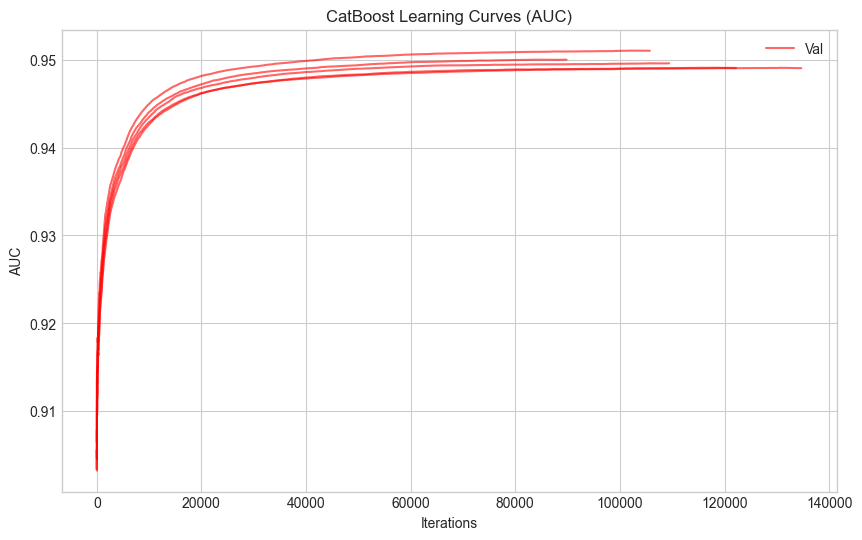

In [12]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='auc', metric_period=metric_period)

### Feature Importance
Average feature importance across folds. This is a sanity check (not a causal explanation).

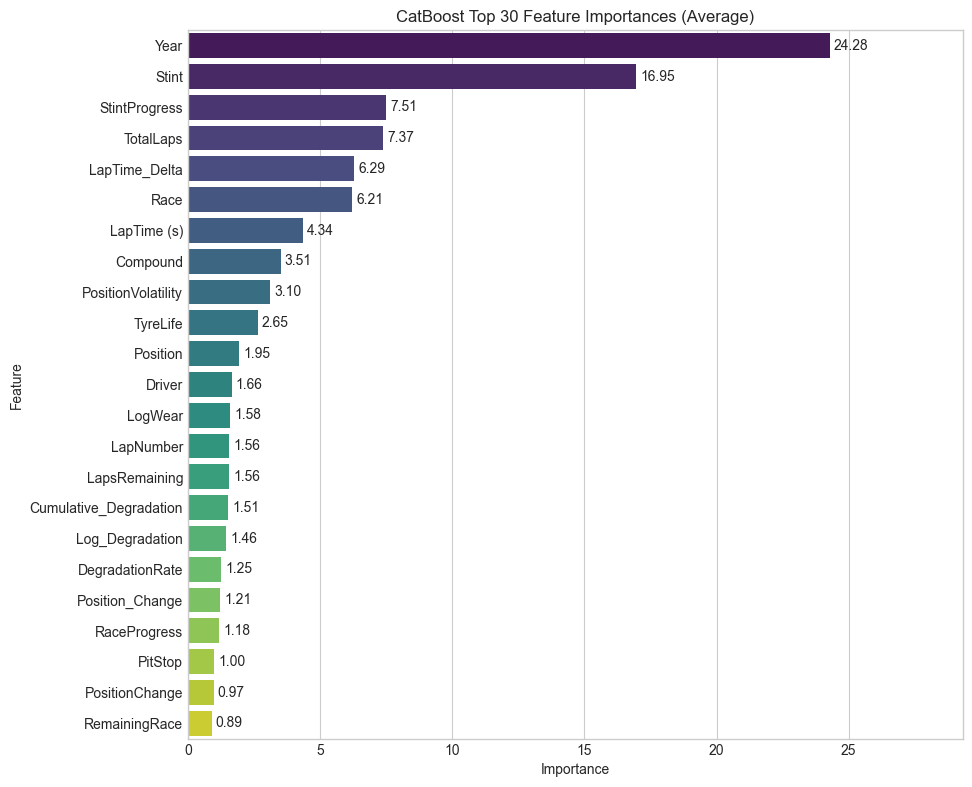

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Check if the model is over-predicting a specific irrigation level.  `y` is the actual ground truth, `oof_preds` is the argmax predictions.

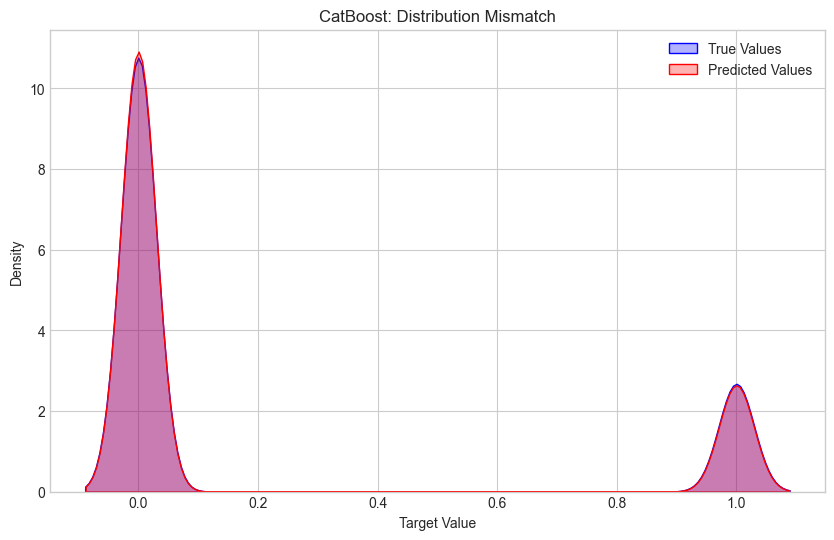

In [14]:
mviz.plot_distribution_mismatch(y_true=y, y_preds=oof_preds)

### ROC Curves (One-vs-Rest)
The ROC curve visualizes the trade-off between the True Positive Rate and False Positive Rate for each class. In this multi-class setting, we look for high AUC scores across all three irrigation levels.

<Figure size 800x600 with 0 Axes>

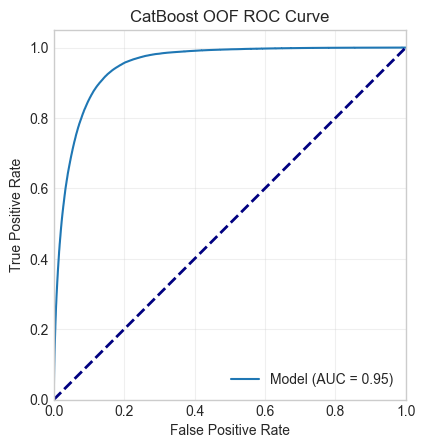

In [15]:
mviz.plot_roc_curve(y_true=y, y_score=oof_probs, title='CatBoost OOF ROC Curve')

### Confusion Matrix (Out-of-Fold)
The confusion matrix helps identify specific error modes by showing which classes the model frequently confuses. For example, it reveals if the model often predicts "Medium Irrigation" when the actual need is "High." Since this is a multi-class task, predictions are determined by selecting the class with the highest predicted probability (**Argmax**).

Normalized confusion matrix


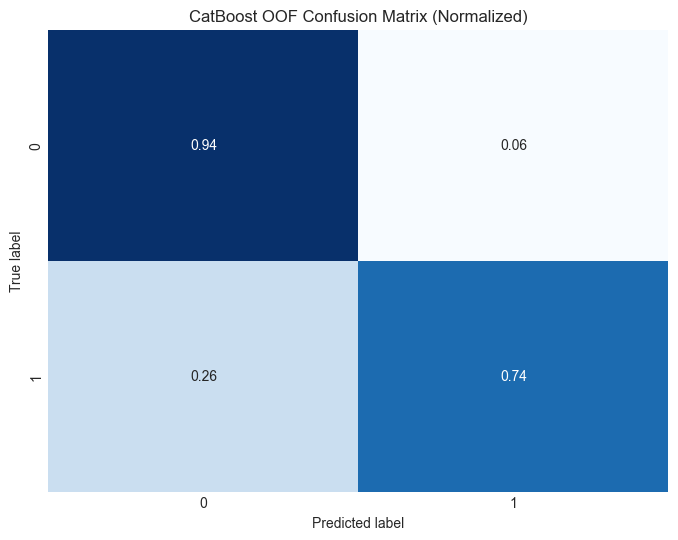

In [16]:
mviz.plot_confusion_matrix(y_true=y, y_pred=oof_preds, classes=[0,1], normalize=True, title='CatBoost OOF Confusion Matrix (Normalized)')

## Prepare Submission

We generate the final submission file according to the competition's schema. The primary evaluation metric is **ROC AUC**, so the submission requires the **probability** of the positive class (`PitNextLap`).

Unlike a hard classification, where we would use a threshold (like 0.5) to decide between 0 and 1, we provide the continuous probability score to allow for nuanced evaluation of the model's confidence across the entire test set.

In [17]:
submission_df = helper.read_dataset('submission')

# Identify the prediction column from the sample submission
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(test_probs)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,PitNextLap
0,439140,0.006
1,439141,0.003
2,439142,0.004
3,439143,0.132
4,439144,0.843
5,439145,0.501
6,439146,0.001
7,439147,0.003
8,439148,0.020
9,439149,0.003


In [18]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) probabilities and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).
  
For this binary classification task, we save the probability scores for the `PitNextLap` event. Saving these raw probabilities is essential for:

- **Weighted Blending**: Combining multiple models by averaging their confidence scores.
- **Stacking**: Using these probabilities as "meta-features" for a secondary model.
- **Calibration Analysis**: Evaluating how well the model's predicted probability aligns with the actual frequency of pit stops.


In [19]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({
    'id': training_df['id'].values,
    'prob_catboost': oof_probs,
    'target': y.values
})
oof_df.to_csv(f'{output_dir}/catboost_oof_probs.csv', index=False)

test_pred_df = pd.DataFrame({
    'id': test_df['id'].values,
    'prob_catboost': test_probs
})
test_pred_df.to_csv(f'{output_dir}/catboost_test_probs.csv', index=False)

print(f'Saved for Blending: {output_dir}/catboost_oof_probs.csv, {output_dir}/catboost_test_probs.csv')

Saved for Blending: predictions/catboost_oof_probs.csv, predictions/catboost_test_probs.csv
